# Bleeding vs ischaemic CATE — the treatment trade-off plane

The per-endpoint causal forests give each patient a CATE for **every** outcome, so we can look
at more than one endpoint at a time. This notebook puts a patient's **bleeding** CATE on one axis
and an **ischaemic** CATE on the other and asks the clinical question the single-endpoint views
cannot: *are there patients who would gain a lot from abbreviating on bleeding but pay a large
ischaemic penalty for it?* Those are the patients for whom the abbreviate-vs-prolong decision is a
genuine trade-off rather than a free lunch, and if they cluster together they define a subgroup
worth flagging.

**Treatment coding (identical to nb 06/07):** `T = 1` prolonged DAPT, `T = 0` abbreviated DAPT, so

$$\text{CATE}_k(x) = \operatorname{risk}_k(\text{prolonged}) - \operatorname{risk}_k(\text{abbreviated}).$$

Read as the **benefit of abbreviating**: `CATE_k > 0` → abbreviating *lowers* endpoint `k`
(a benefit of shortening); `CATE_k < 0` → abbreviating *raises* it (a harm of shortening).
Both axes use this same signed convention, so the four quadrants have a fixed meaning:

| quadrant | bleeding CATE | ischaemic CATE | reading |
|---|---|---|---|
| top-right | > 0 | > 0 | **win–win**: abbreviate (fewer bleeds *and* fewer ischaemic events) |
| **bottom-right** | **> 0** | **< 0** | **trade-off / conflict**: abbreviating stops bleeds but costs ischaemic events |
| bottom-left | < 0 | < 0 | **lose–lose**: keep prolonged |
| top-left | < 0 | > 0 | prolonging bleeds them yet abbreviating still costs ischaemia |

The **bottom-right** quadrant is the one we hunt for.

The model is loaded **only by path** (see the CONFIG cell): point the two axes at any saved
`CausalMultiOutputPipeline` — the tuned multi-output causal forest here, a preset level, the BCF,
or a per-endpoint tuned forest — and the rest of the notebook is unchanged.


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

HERE = os.getcwd()
MODELS_DIR = os.path.normpath(os.path.join(HERE, "..", "models"))
DATA_DIR   = os.path.normpath(os.path.join(HERE, "..", "..", "data"))
CF_DIR     = os.path.join(MODELS_DIR, "CausalForest")
FIG_DIR    = os.path.join(CF_DIR, "TRADEOFF")
os.makedirs(FIG_DIR, exist_ok=True)
print("models dir:", MODELS_DIR)

models dir: /home/tpioda/Bachelor-Thesis/Meta-learning/models


## 1 · Configuration — *change the model here*

Everything downstream reads the two axes from `AXES`. Each entry is a `(path, endpoint)` pair:

* `path` — any saved `CausalMultiOutputPipeline` (`.joblib`). It may be the bare pipeline
  (nb 06's multi-output fit) or a `dict` wrapping it under `"pipe"` (the per-endpoint tuned
  forests from `analyze_ischemic_tuning.py`).
* `endpoint` — the outcome to read, either a label from
  `["barc_235", "death", "mi", "stroke", "bleed"]` or an integer column index. For a
  single-endpoint (`dict`) model the label is auto-detected, so `0` always works.

To score a **different model**, edit only the paths below — e.g. swap
`CausalForest_multioutput_tuned.joblib` for `.../BCF/BCF_multioutput.joblib` or
`CausalForest_multioutput_flexible.joblib`.

In [2]:
# ============================ CONFIG ============================
# The bleeding axis (x) and the ischaemic axes (y candidates). Swap paths to change model.
MULTIOUT = os.path.join(CF_DIR, "CausalForest_multioutput_tuned.joblib")

BLEED_AXIS = {"path": MULTIOUT, "endpoint": "bleed"}          # x-axis: bleeding benefit of abbreviating

ISCHAEMIC_AXES = {                                            # y-axis candidates
    "death":  {"path": MULTIOUT, "endpoint": "death"},
    "mi":     {"path": MULTIOUT, "endpoint": "mi"},
    "stroke": {"path": MULTIOUT, "endpoint": "stroke"},
}
ISCHAEMIC_WEIGHTS = {"death": 1.0, "mi": 1.0, "stroke": 1.0}  # weights for the combined ischaemic score
PRIMARY_ISCHAEMIC = "mi"      # single endpoint drawn on the main 2-D plane (see the sign check below)

CONFLICT_PCT = 15.0           # top-% by conflict score flagged as the trade-off subgroup
RANDOM_STATE = 42
# ===============================================================
print("bleeding axis :", BLEED_AXIS)
print("ischaemic axes:", list(ISCHAEMIC_AXES))
print("primary ischaemic endpoint (main plane y):", PRIMARY_ISCHAEMIC)

bleeding axis : {'path': '/home/tpioda/Bachelor-Thesis/Meta-learning/models/CausalForest/CausalForest_multioutput_tuned.joblib', 'endpoint': 'bleed'}
ischaemic axes: ['death', 'mi', 'stroke']
primary ischaemic endpoint (main plane y): mi


## 2 · Model-agnostic CATE loader

`cate_for(axis)` is the single point of contact with the model: it opens the joblib, applies
**that model's own** imputer + scaler to the shared raw `X`, and returns the per-patient CATE for
the requested endpoint. Because each saved pipeline carries its own preprocessing, mixing models
across axes stays correct — only the CONFIG paths decide what is loaded.

In [3]:
TARGET_LABELS = ["barc_235", "death", "mi", "stroke", "bleed"]  # column order of Y / the fitted models

_PIPE_CACHE = {}

def load_cf_pipeline(path):
    '''Return (pipeline, label->index). Handles a bare CausalMultiOutputPipeline or a
    dict {"pipe":..., "outcome":...} from the per-endpoint tuners.'''
    if path in _PIPE_CACHE:
        return _PIPE_CACHE[path]
    obj = joblib.load(path)
    if isinstance(obj, dict):
        pipe = obj["pipe"]
        # single-endpoint model: its one forest sits at index 0
        label = obj.get("outcome")
        idx_map = {label: 0} if label else {}
        idx_map.setdefault(0, 0)
    else:
        pipe = obj
        n = len(pipe.models)
        idx_map = {lab: i for i, lab in enumerate(TARGET_LABELS[:n])}
    _PIPE_CACHE[path] = (pipe, idx_map)
    return pipe, idx_map

def _resolve_idx(endpoint, idx_map, n_models):
    if isinstance(endpoint, (int, np.integer)):
        return int(endpoint)
    if endpoint in idx_map:
        return idx_map[endpoint]
    if endpoint in TARGET_LABELS and TARGET_LABELS.index(endpoint) < n_models:
        return TARGET_LABELS.index(endpoint)
    raise KeyError(f"endpoint {endpoint!r} not available (have {idx_map})")

def cate_for(axis, X_raw):
    '''Per-patient CATE for one CONFIG axis, using the model's own preprocessing.'''
    pipe, idx_map = load_cf_pipeline(axis["path"])
    idx = _resolve_idx(axis["endpoint"], idx_map, len(pipe.models))
    X_df = pd.DataFrame(X_raw).apply(pd.to_numeric, errors="coerce")
    X_scaled = pipe.scaler.transform(pipe.imputer_x.transform(X_df))
    model = pipe.models[idx]
    if model is None:
        raise ValueError(f"model index {idx} is None in {os.path.basename(axis['path'])}")
    return np.asarray(model.effect(X_scaled)).ravel()

print("loaders ready")

loaders ready


## 3 · Data

`tuning_data.npz` holds the exact `X / Y / T` the forests were fit on (numeric features in fitted
order), so every model's CATE is aligned to the same patients. Feature names come from
`X_features.parquet` for the subgroup profiling later.

In [4]:
d = np.load(os.path.join(HERE, "tuning_data.npz"), allow_pickle=True)
X_raw = d["X"]                       # (n, 180) object -> numeric
T = d["T"].astype(int)
Y = pd.DataFrame(d["Y"], columns=TARGET_LABELS).apply(pd.to_numeric, errors="coerce")
n = X_raw.shape[0]

# feature names in the model's column order (numeric columns of X_features.parquet)
try:
    Xfeat = pd.read_parquet(os.path.join(DATA_DIR, "X_features.parquet"))
    feat_names = list(Xfeat.select_dtypes(include=[np.number]).columns)
    if len(feat_names) != X_raw.shape[1]:
        feat_names = [f"x{i}" for i in range(X_raw.shape[1])]
except Exception:
    feat_names = [f"x{i}" for i in range(X_raw.shape[1])]

print(f"n = {n} patients | {X_raw.shape[1]} features | "
      f"{int((T==1).sum())} prolonged, {int((T==0).sum())} abbreviated")

n = 4579 patients | 63 features | 2284 prolonged, 2295 abbreviated


## 4 · Sign & calibration sanity check *(read this before trusting an axis)*

A causal forest's **average** CATE should sit near the trial's raw ATE
$\big(\bar Y_{T=1}-\bar Y_{T=0}\big)$ and, above all, **agree in sign**. Where it does not, the
endpoint's heterogeneity signal is unreliable and a poor choice of axis. We therefore print, per
endpoint, the raw ATE next to the model's mean CATE and flag sign agreement.

In [5]:
rows = []
for lab in TARGET_LABELS:
    ate = Y.loc[T == 1, lab].mean() - Y.loc[T == 0, lab].mean()
    c = cate_for({"path": MULTIOUT, "endpoint": lab}, X_raw)
    rows.append({"endpoint": lab, "raw_ATE": ate, "model_meanCATE": c.mean(),
                 "model_stdCATE": c.std(),
                 "sign_ok": "yes" if np.sign(ate) == np.sign(c.mean()) else "NO",
                 "spread": "flat" if c.std() < 1e-3 else "ok"})
sign_tbl = pd.DataFrame(rows).set_index("endpoint")
print(sign_tbl.round(4).to_string())
print("\n-> use endpoints with sign_ok=yes AND spread=ok as axes; the others are shown but "
      "flagged.\n   (barc_235's forest CATE is sign-flipped vs the ATE, so `bleed` is the "
      "default bleeding axis.)")

          raw_ATE  model_meanCATE  model_stdCATE sign_ok spread
endpoint                                                       
barc_235   0.0279          0.0293         0.0041     yes     ok
death      0.0031          0.0033         0.0035     yes     ok
mi        -0.0047         -0.0043         0.0034     yes     ok
stroke     0.0048          0.0044         0.0065     yes     ok
bleed      0.0451          0.0474         0.0056     yes     ok

-> use endpoints with sign_ok=yes AND spread=ok as axes; the others are shown but flagged.
   (barc_235's forest CATE is sign-flipped vs the ATE, so `bleed` is the default bleeding axis.)


## 5 · Per-patient CATEs and the conflict score

Assemble one row per patient: the bleeding-axis CATE, each ischaemic CATE, a weighted **combined
ischaemic** benefit, and a **conflict score**

$$\text{conflict} = z(\text{bleed benefit}) - z(\text{ischaemic benefit}),$$

standardised so the two miscalibrated scales are comparable. It is large-positive exactly for the
bottom-right patients (abbreviating helps bleeding but hurts ischaemia).

In [6]:
df = pd.DataFrame(index=np.arange(n))
df["bleed"] = cate_for(BLEED_AXIS, X_raw)
for name, ax in ISCHAEMIC_AXES.items():
    df[name] = cate_for(ax, X_raw)

w = ISCHAEMIC_WEIGHTS
df["ischaemic_combined"] = sum(w[k] * df[k] for k in ISCHAEMIC_AXES) / sum(w.values())

def _z(s):
    return (s - s.mean()) / (s.std() if s.std() > 0 else 1.0)

# conflict = abbreviating is good for bleeding (high) but bad for ischaemia (low)
df["conflict"] = _z(df["bleed"]) - _z(df["ischaemic_combined"])

print(df[["bleed", *ISCHAEMIC_AXES, "ischaemic_combined", "conflict"]].describe().round(4).to_string())

           bleed      death         mi     stroke  ischaemic_combined   conflict
count  4579.0000  4579.0000  4579.0000  4579.0000           4579.0000  4579.0000
mean      0.0474     0.0033    -0.0043     0.0044              0.0011     0.0000
std       0.0056     0.0035     0.0034     0.0065              0.0023     1.4412
min       0.0324    -0.0055    -0.0165    -0.0070             -0.0043    -4.4044
25%       0.0434     0.0007    -0.0064    -0.0004             -0.0007    -1.0148
50%       0.0471     0.0021    -0.0040     0.0022              0.0008    -0.0188
75%       0.0511     0.0054    -0.0020     0.0092              0.0028     0.9805
max       0.0678     0.0192     0.0061     0.0215              0.0082     4.6228


## 6 · The trade-off plane

`x = bleeding benefit of abbreviating`, `y = ischaemic benefit of abbreviating` (primary endpoint).
Zero lines split the four quadrants above; the density (hexbin) shows where the mass actually sits,
and the points are tinted by the conflict score so the **bottom-right** trade-off patients stand
out. The shaded box marks the flagged conflict subgroup's region.

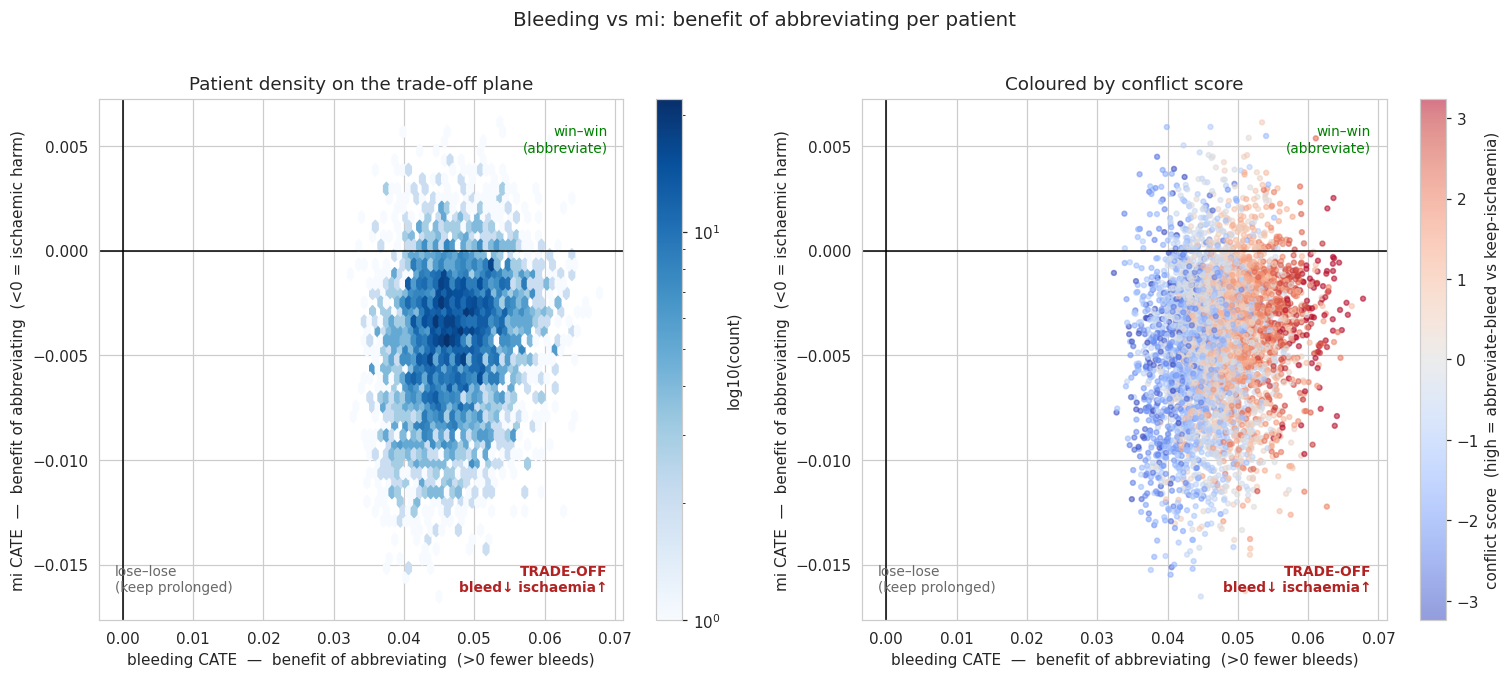

In [7]:
yname = PRIMARY_ISCHAEMIC
x, y = df["bleed"].to_numpy(), df[yname].to_numpy()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))

# -- left: density
hb = axL.hexbin(x, y, gridsize=45, cmap="Blues", mincnt=1, bins="log")
fig.colorbar(hb, ax=axL, label="log10(count)")
axL.set_title("Patient density on the trade-off plane")

# -- right: points tinted by conflict
sc = axR.scatter(x, y, c=df["conflict"], cmap="coolwarm", s=10, alpha=0.55,
                 vmin=-np.abs(df["conflict"]).quantile(0.98),
                 vmax=np.abs(df["conflict"]).quantile(0.98))
fig.colorbar(sc, ax=axR, label="conflict score  (high = abbreviate-bleed vs keep-ischaemia)")
axR.set_title("Coloured by conflict score")

for ax in (axL, axR):
    ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("bleeding CATE  —  benefit of abbreviating  (>0 fewer bleeds)")
    ax.set_ylabel(f"{yname} CATE  —  benefit of abbreviating  (<0 = ischaemic harm)")
    ax.annotate("win–win\n(abbreviate)", (0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color="green")
    ax.annotate("TRADE-OFF\nbleed↓ ischaemia↑", (0.97, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=9, color="firebrick", weight="bold")
    ax.annotate("lose–lose\n(keep prolonged)", (0.03, 0.05), xycoords="axes fraction",
                ha="left", va="bottom", fontsize=9, color="dimgray")

fig.suptitle(f"Bleeding vs {yname}: benefit of abbreviating per patient", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"tradeoff_bleed_vs_{yname}.png"), dpi=150, bbox_inches="tight")
plt.show()

### Bleeding against each ischaemic endpoint

The tension is endpoint-specific — MI carries the classic ischaemic benefit of *longer* DAPT,
while death/stroke are weaker. Small multiples make each pairing visible; the Pearson `r` in each
title is the bleeding–ischaemia CATE correlation (negative `r` ⇒ the two goals genuinely pull
apart across patients).

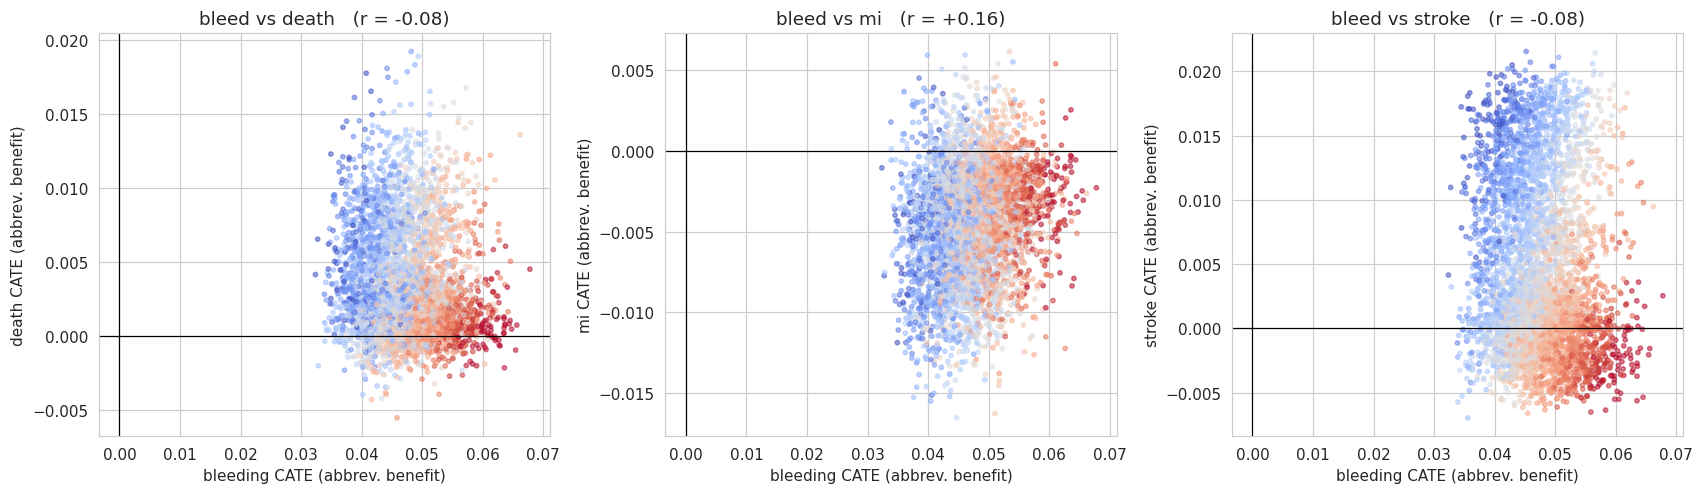

In [8]:
fig, axes = plt.subplots(1, len(ISCHAEMIC_AXES), figsize=(5.2 * len(ISCHAEMIC_AXES), 4.6),
                         squeeze=False)
for ax, name in zip(axes.ravel(), ISCHAEMIC_AXES):
    r = np.corrcoef(df["bleed"], df[name])[0, 1]
    ax.scatter(df["bleed"], df[name], c=df["conflict"], cmap="coolwarm", s=8, alpha=0.5,
               vmin=-np.abs(df["conflict"]).quantile(0.98), vmax=np.abs(df["conflict"]).quantile(0.98))
    ax.axvline(0, color="k", lw=0.8); ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"bleed vs {name}   (r = {r:+.2f})")
    ax.set_xlabel("bleeding CATE (abbrev. benefit)")
    ax.set_ylabel(f"{name} CATE (abbrev. benefit)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_small_multiples.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7 · Do the patients cluster?

Cluster on the **standardised** `(bleeding, combined-ischaemic)` plane so neither miscalibrated
scale dominates. `k` is chosen by the best silhouette over `k = 2…6`. A real trade-off subgroup
would show up as its own cloud in the bottom-right; if the field is one diffuse blob the clusters
are arbitrary slices — the honest null this cohort has shown throughout.

In [13]:
feat = df[['conflict']].to_numpy()
Z = StandardScaler().fit_transform(feat)

sil = {}
for k in range(3, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z)
    sil[k] = silhouette_score(Z, km.labels_)
best_k = max(sil, key=sil.get)
print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()}, "-> best k =", best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Z)
df["cluster"] = km.labels_

# centroids back in raw CATE units
cent = (df.groupby("cluster")[["bleed", "ischaemic_combined"]]
          .agg(["mean", "size"]))
cent.columns = ["bleed_meanCATE", "n_a", "isch_meanCATE", "n"]
cent = cent[["bleed_meanCATE", "isch_meanCATE", "n"]]
# the trade-off cluster = highest bleed benefit with negative ischaemic benefit
cent["tradeoff_rank"] = cent["bleed_meanCATE"] - cent["isch_meanCATE"]
print(cent.round(4).sort_values("tradeoff_rank", ascending=False).to_string())

silhouette by k: {3: np.float64(0.535), 4: np.float64(0.53), 5: np.float64(0.523), 6: np.float64(0.526)} -> best k = 3
         bleed_meanCATE  isch_meanCATE     n  tradeoff_rank
cluster                                                    
1                0.0526        -0.0008  1259         0.0535
0                0.0469         0.0009  2052         0.0460
2                0.0430         0.0034  1268         0.0397


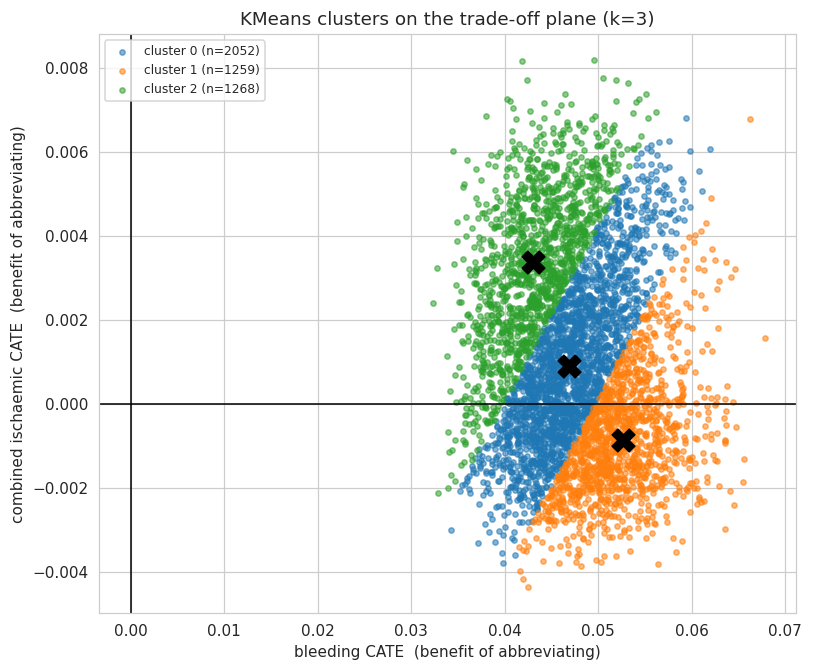

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 6.2))
palette = sns.color_palette("tab10", best_k)
for cl in range(best_k):
    m = df["cluster"] == cl
    ax.scatter(df.loc[m, "bleed"], df.loc[m, "ischaemic_combined"],
               s=12, alpha=0.55, color=palette[cl], label=f"cluster {cl} (n={int(m.sum())})")
# centroid markers
cc = df.groupby("cluster")[["bleed", "ischaemic_combined"]].mean()
ax.scatter(cc["bleed"], cc["ischaemic_combined"], marker="X", s=220, c="black", zorder=5)
ax.axvline(0, color="k", lw=1); ax.axhline(0, color="k", lw=1)
ax.set_xlabel("bleeding CATE  (benefit of abbreviating)")
ax.set_ylabel("combined ischaemic CATE  (benefit of abbreviating)")
ax.set_title(f"KMeans clusters on the trade-off plane (k={best_k})")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_clusters.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8 · The conflict subgroup

Flag the top **`CONFLICT_PCT`%** by conflict score (data-driven, independent of `k`) as the
trade-off subgroup and compare it with the rest: its mean CATEs, and its **observed** event rates
by arm. This is descriptive / in-sample — a hypothesis-generating profile, not a trial estimate.

In [11]:
thr = np.percentile(df["conflict"], 100 - CONFLICT_PCT)
df["conflict_flag"] = df["conflict"] >= thr
grp = df["conflict_flag"]
print(f"conflict subgroup: {int(grp.sum())} patients ({grp.mean()*100:.1f}%), "
      f"conflict score >= {thr:.2f}\n")

summ = pd.DataFrame({
    "conflict_subgroup": df.loc[grp, ["bleed", *ISCHAEMIC_AXES, "ischaemic_combined"]].mean(),
    "rest":              df.loc[~grp, ["bleed", *ISCHAEMIC_AXES, "ischaemic_combined"]].mean(),
})
print("mean CATE (benefit of abbreviating):")
print(summ.round(4).to_string())

print("\nobserved event rate by arm within each group (raw outcomes):")
for lab in TARGET_LABELS:
    for gname, gmask in [("conflict", grp.values), ("rest", (~grp).values)]:
        sub = gmask
        r1 = Y.loc[sub & (T == 1), lab].mean()
        r0 = Y.loc[sub & (T == 0), lab].mean()
        print(f"  {lab:9s} [{gname:8s}]  prolonged={r1:.3f}  abbreviated={r0:.3f}  diff={r1-r0:+.3f}")

conflict subgroup: 687 patients (15.0%), conflict score >= 1.53

mean CATE (benefit of abbreviating):
                    conflict_subgroup    rest
bleed                          0.0547  0.0461
death                          0.0012  0.0036
mi                            -0.0037 -0.0044
stroke                        -0.0010  0.0054
ischaemic_combined            -0.0012  0.0015

observed event rate by arm within each group (raw outcomes):
  barc_235  [conflict]  prolonged=0.140  abbreviated=0.028  diff=+0.112
  barc_235  [rest    ]  prolonged=0.084  abbreviated=0.071  diff=+0.013
  death     [conflict]  prolonged=0.003  abbreviated=0.014  diff=-0.011
  death     [rest    ]  prolonged=0.022  abbreviated=0.016  diff=+0.006
  mi        [conflict]  prolonged=0.015  abbreviated=0.037  diff=-0.022
  mi        [rest    ]  prolonged=0.023  abbreviated=0.024  diff=-0.002
  stroke    [conflict]  prolonged=0.000  abbreviated=0.014  diff=-0.014
  stroke    [rest    ]  prolonged=0.012  abbreviated=0.0

### Who are they? Covariate profile

Standardised mean difference (SMD) of each feature, conflict subgroup minus the rest; the largest
`|SMD|` features are what the model keys on to place a patient in the trade-off corner. `|SMD| > 0.2`
is a conventional "meaningful imbalance" line.

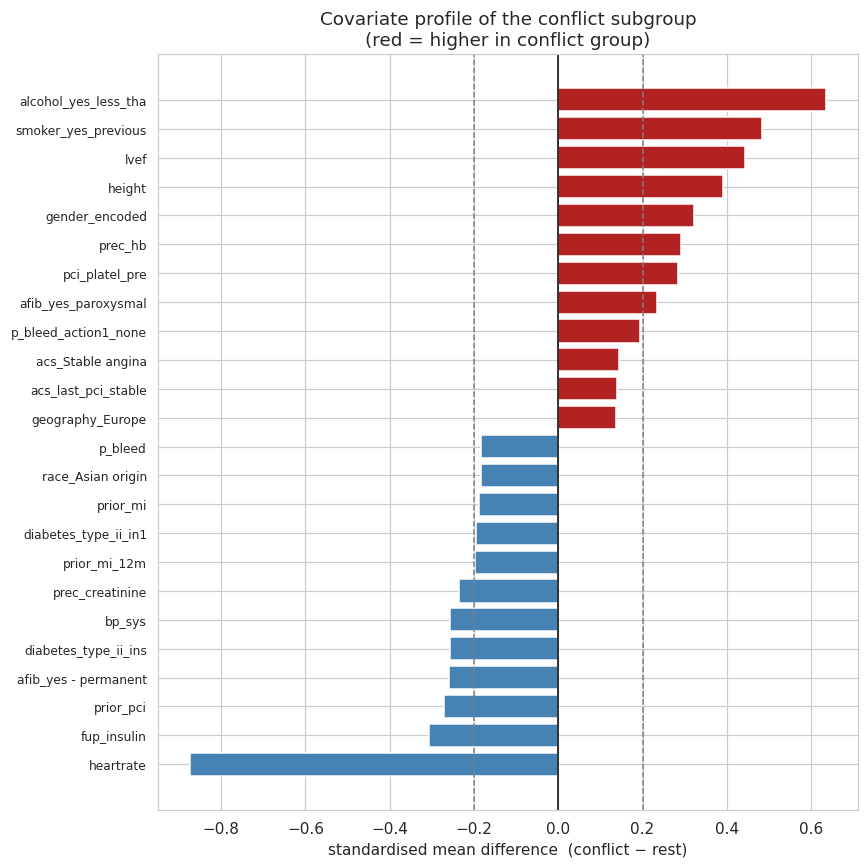

top features higher in the conflict subgroup:
alcohol_yes_less_tha    0.636
smoker_yes_previous     0.483
lvef                    0.443
height                  0.391
gender_encoded          0.322
prec_hb                 0.291
pci_platel_pre          0.284
afib_yes_paroxysmal     0.236

top features lower in the conflict subgroup:
heartrate              -0.875
fup_insulin            -0.307
prior_pci              -0.271
afib_yes - permanent   -0.260
diabetes_type_ii_ins   -0.257
bp_sys                 -0.257
prec_creatinine        -0.236
prior_mi_12m           -0.198


In [12]:
Xnum = pd.DataFrame(X_raw, columns=feat_names).apply(pd.to_numeric, errors="coerce")
g1, g0 = Xnum[grp.values], Xnum[(~grp).values]
m1, m0 = g1.mean(), g0.mean()
sd = np.sqrt((g1.var() + g0.var()) / 2).replace(0, np.nan)
smd = ((m1 - m0) / sd).dropna().sort_values()
top = pd.concat([smd.head(12), smd.tail(12)])

fig, ax = plt.subplots(figsize=(8, 8))
colors = ["firebrick" if v > 0 else "steelblue" for v in top.values]
ax.barh(range(len(top)), top.values, color=colors)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.axvline(0, color="k", lw=1)
ax.axvline(0.2, color="gray", ls="--", lw=1); ax.axvline(-0.2, color="gray", ls="--", lw=1)
ax.set_xlabel("standardised mean difference  (conflict − rest)")
ax.set_title("Covariate profile of the conflict subgroup\n(red = higher in conflict group)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "tradeoff_subgroup_profile.png"), dpi=150, bbox_inches="tight")
plt.show()

print("top features higher in the conflict subgroup:")
print(smd.tail(8)[::-1].round(3).to_string())
print("\ntop features lower in the conflict subgroup:")
print(smd.head(8).round(3).to_string())

## 9 · How to read this — and how to swap the model

**Swapping model.** Change only the `path` values in the CONFIG cell (§1). Any saved
`CausalMultiOutputPipeline` works — a different flexibility preset
(`CausalForest_multioutput_flexible.joblib`), the BCF (`../models/BCF/BCF_multioutput.joblib`),
or a per-endpoint tuned forest (`dict`-wrapped, endpoint auto-detected). The loader applies each
model's own imputer/scaler, so axes may even come from different models.

**Honest caveats (this cohort).**

* **Magnitudes are not calibrated.** The forests' mean CATEs drift from the raw ATEs (e.g. `bleed`
  ≈ +0.54 vs ATE ≈ +0.05) and `barc_235` is even **sign-flipped**, which is why the default
  bleeding axis is `bleed` and the sign check in §4 gates every axis. Treat the axes as a
  *relative* heterogeneity ranking, not absolute risk differences — the clustering is done on
  standardised values for exactly this reason.
* **Heterogeneity is weak.** Consistent with nb 07 and the decision-rule analyses, the spread is
  small and the clusters largely partition one diffuse cloud; check the silhouette in §7 before
  reading a "subgroup" as real. The conflict subgroup is a hypothesis-generating slice, not a
  validated responder group.
* **In-sample.** CATEs and the profile use full-data (in-sample) predictions — descriptive, not a
  cross-fitted policy estimate.
